# 28_test_monthly_three_methods_validation.ipynb

## Purpose

Use the **monthly long satellite dataset** to compare three methods on the same held-out P10 validation exercise:

1. **ASCM alone** — follows the Notebook 15/18 ASCM workflow.
2. **SCM with multiple outcomes** — follows Notebook 22, Experiment 2.
3. **Ridge ASCM + multiple outcomes** — applies the Ridge ASCM correction to the Notebook 22 multiple-outcome SCM problem.

### Monthly validation design

- Input folder: `finals/monthly_long_datasets/`
- Training: **P01-P09**
- Held-out validation: **P10**
- Sentinel-2 treatment positions: **1-15**
- Sentinel-1 treatment positions: **15-27**
- Treatment position 15 is intentionally included in both sensors.
- Use **all 10 matched geographic donors** for every treatment site.
- P10 is never used for weight estimation or lambda selection.

### Method 1 — ASCM alone

This reproduces the Notebook 15/18 style ASCM preprocessing.

For each treatment site × sensor:

1. Use donor observations in P01-P09 to calculate one mean and SD for each band.
2. Standardize treated and donor values using those donor-based training scalers.
3. Stack all usable **period × band** training cells.
4. Estimate ordinary SCM weights internally.
5. Select Ridge ASCM lambda by leave-one-training-period-out cross-validation using only P01-P09.
6. Refit Ridge ASCM on all P01-P09.
7. Predict P10 using the ASCM weights.

No within-site demeaning and no multiple-outcome `V` weighting are used in this method.

### Method 2 — SCM with multiple outcomes

This follows Notebook 22, Experiment 2.

For each treatment site × sensor:

1. Demean each site × band over P01-P09.
2. Stack all usable **period × band** cells.
3. Remove cells with missing treated/donor values.
4. Remove zero-cross-sectional-SD cells.
5. Standardize each usable cell by its cross-sectional SD.
6. Give each band equal total weight in the matching objective.
7. Estimate one common convex donor-weight vector.

SCM solves:

$$
\hat{w}^{MO-SCM}
=
\arg\min_{w \ge 0,\;\mathbf{1}^{\top}w=1}
\left(Z_i-Z_J^{\top}w\right)^{\top}
V
\left(Z_i-Z_J^{\top}w\right).
$$

### Method 3 — Ridge ASCM + multiple outcomes

Starting from the multiple-outcome SCM weights, estimate:

$$
\hat{w}^{MO-ASCM}(\lambda)
=
\arg\min_{\mathbf{1}^{\top}w=1}
\left[
\frac{1}{2\lambda}
\left(Z_i-Z_J^{\top}w\right)^{\top}
V
\left(Z_i-Z_J^{\top}w\right)
+
\frac{1}{2}
\left\|w-\hat{w}^{MO-SCM}\right\|_2^2
\right].
$$

Negative ASCM weights are allowed. Lambda is selected using only P01-P09.

### Final comparison

The notebook reports P10 validation RMSE for each band under:

- `ASCM_alone`
- `SCM_multiple_outcomes`
- `Ridge_ASCM_multiple_outcomes`

and creates one RMSE figure for Sentinel-1 and one for Sentinel-2.


## Block 1 — Packages


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import rasterio

from scipy.optimize import minimize
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

print("Packages loaded.")


Packages loaded.


## Block 2 — Paths, periods, sensors, and numerical settings


In [2]:
# =============================================================================
# PATHS
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets"
)

MONTHLY_DIR = BASE_DIR / "finals" / "monthly_long_datasets"

SELECTED_SAMPLE_FILE = (
    BASE_DIR / "finals" / "daily_datasets" / "selected_site_sample.csv"
)

OUTPUT_DIR = (
    BASE_DIR / "test" / "monthly_three_methods_validation"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# VALIDATION DESIGN
# =============================================================================

TRAIN_PERIODS = [f"P{i:02d}" for i in range(1, 10)]   # P01-P09
VALIDATION_PERIOD = "P10"

# P11 / September transition and later post periods are not needed here.
PERIODS_NEEDED = TRAIN_PERIODS + [VALIDATION_PERIOD]

# =============================================================================
# SENSORS / MULTIPLE OUTCOMES
# =============================================================================

BANDS = {
    "sentinel1": ["VV", "VH", "VV_minus_VH"],
    "sentinel2": ["B2", "B3", "B4", "B8", "B11", "B12", "NDVI", "NDWI"],
}

SENSORS_TO_RUN = ["sentinel1", "sentinel2"]


# =============================================================================
# TREATMENT-SITE RESTRICTION BY SENSOR
# =============================================================================
# 1-based treatment-site position in the treatment_sites list.
# User-specified design:
#   Sentinel-2: treatment sites 1-15
#   Sentinel-1: treatment sites 15-27
# Treatment site 15 is intentionally included in both sensors.
SENSOR_TREATMENT_NUMBER_RANGES = {
    "sentinel2": (1, 15),
    "sentinel1": (15, 27),
}

FEATURES = {
    sensor: [f"mean_{band}" for band in bands]
    for sensor, bands in BANDS.items()
}

# =============================================================================
# NUMERICAL SETTINGS
# =============================================================================

SD_TOL = 1e-10
WEIGHT_TOL = 1e-10
OPT_FTOL = 1e-12
OPT_MAXITER = 5000

# Same lambda grid used in Notebook 18.
LAMBDA_GRID = np.logspace(-4, 4, 81)

print("Input folder :", MONTHLY_DIR)
print("Output folder:", OUTPUT_DIR)
print("Training     :", TRAIN_PERIODS)
print("Validation   :", VALIDATION_PERIOD)
print("Sensors      :", SENSORS_TO_RUN)


Input folder : /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/finals/monthly_long_datasets
Output folder: /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation
Training     : ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09']
Validation   : P10
Sensors      : ['sentinel1', 'sentinel2']


## Block 3 — Verify paths and load the fixed treatment/counterfactual sample


In [3]:
def clean_id(value):
    if pd.isna(value):
        return pd.NA
    value = str(value).strip()
    if value.endswith(".0"):
        value = value[:-2]
    return value

if not MONTHLY_DIR.exists():
    raise FileNotFoundError(f"Monthly input folder not found:\n{MONTHLY_DIR}")

if not SELECTED_SAMPLE_FILE.exists():
    raise FileNotFoundError(f"Selected sample file not found:\n{SELECTED_SAMPLE_FILE}")

sample = pd.read_csv(SELECTED_SAMPLE_FILE)

required_sample_columns = [
    "site_id",
    "group",
    "matched_treatment_site_id",
    "control_rank",
]

missing = [c for c in required_sample_columns if c not in sample.columns]
if missing:
    raise ValueError(f"selected_site_sample.csv missing columns: {missing}")

sample["site_id"] = sample["site_id"].apply(clean_id).astype("string")
sample["group"] = sample["group"].astype(str).str.strip().str.lower()
sample["matched_treatment_site_id"] = (
    sample["matched_treatment_site_id"].apply(clean_id).astype("string")
)
sample["control_rank"] = pd.to_numeric(sample["control_rank"], errors="coerce")

# Make treatment rows self-identifying if their match field is empty.
mask_t = sample["group"].eq("treatment")
sample.loc[mask_t, "matched_treatment_site_id"] = sample.loc[mask_t, "site_id"]

# Keep one row per site.
sample = (
    sample
    .sort_values(["group", "matched_treatment_site_id", "control_rank", "site_id"])
    .drop_duplicates("site_id", keep="first")
    .reset_index(drop=True)
)

treatment_sites = (
    sample.loc[sample["group"].eq("treatment"), "site_id"]
    .dropna()
    .astype(str)
    .tolist()
)

print("Treatment sites:", len(treatment_sites))
print("Counterfactual sites:", int(sample["group"].eq("counterfactual").sum()))


def should_run_treatment_sensor(treatment_number, sensor):
    """Return True if this 1-based treatment number should be run for the sensor."""
    start_num, end_num = SENSOR_TREATMENT_NUMBER_RANGES[sensor]
    return start_num <= treatment_number <= end_num


print("\nTreatment-site ranges by sensor:")
for _sensor, (_start, _end) in SENSOR_TREATMENT_NUMBER_RANGES.items():
    available_end = min(_end, len(treatment_sites))
    if available_end < _start:
        print(f"  {_sensor}: no available treatment sites in requested range {_start}-{_end}")
    else:
        print(f"  {_sensor}: treatment positions {_start}-{available_end}")


Treatment sites: 26
Counterfactual sites: 260

Treatment-site ranges by sensor:
  sentinel2: treatment positions 1-15
  sentinel1: treatment positions 15-26


## Block 4 — Scan monthly TIFFs and extract spatial-mean outcomes

This cell scans P01–P10 directly under `monthly_long_datasets/`.

The parser explicitly supports the current monthly-long filename format, for example:

- `treatment_0015_P01_2023-11-01_2023-11-30_monthly_long_sentinel2.tif`
- `counterfactual_0015_01_P01_2023-11-01_2023-11-30_monthly_long_sentinel2.tif`

Everything before `_P##` is treated as the full `site_id`; the period is taken from `P##`; and the sensor is taken from the final `sentinel1` / `sentinel2` part.


In [4]:
PERIOD_RE = re.compile(r"_(P\d{2})_", re.IGNORECASE)
SENSOR_RE = re.compile(r"(sentinel[12])", re.IGNORECASE)
DATE_RE = re.compile(r"(\d{4}-\d{2}(?:-\d{2})?)")


def parse_monthly_file(path):
    path = Path(path)
    name = path.name

    period_match = PERIOD_RE.search(name)
    sensor_match = SENSOR_RE.search(name)

    if period_match is None or sensor_match is None:
        return None

    # IMPORTANT:
    # Notebook 14 filenames start with the full site_id and then "_P##".
    # Examples:
    #   treatment_0001_P01_2023-11_sentinel1.tif
    #   counterfactual_0001_01_P01_2023-11_sentinel1.tif
    #
    # Taking everything before "_P##" preserves the counterfactual control suffix.
    site_id = name[:period_match.start()].lower()

    if not (
        site_id.startswith("treatment_")
        or site_id.startswith("counterfactual_")
    ):
        return None

    period_id = period_match.group(1).upper()
    sensor = sensor_match.group(1).lower()
    group = "treatment" if site_id.startswith("treatment_") else "counterfactual"

    dates = DATE_RE.findall(name)
    start_date = pd.to_datetime(dates[0], errors="coerce") if len(dates) >= 1 else pd.NaT
    end_date = pd.to_datetime(dates[1], errors="coerce") if len(dates) >= 2 else pd.NaT

    return {
        "site_id": site_id,
        "group": group,
        "period_id": period_id,
        "sensor": sensor,
        "start_date": start_date,
        "end_date": end_date,
        "file_path": str(path),
        "mtime": path.stat().st_mtime,
    }


inventory_records = []
for path in MONTHLY_DIR.rglob("*.tif"):
    record = parse_monthly_file(path)
    if record is None:
        continue
    if record["period_id"] not in PERIODS_NEEDED:
        continue
    if record["sensor"] not in SENSORS_TO_RUN:
        continue
    inventory_records.append(record)

inventory = pd.DataFrame(inventory_records)

if inventory.empty:
    raise RuntimeError(
        "No monthly P01-P10 TIFFs were found under monthly_long_datasets."
    )

selected_ids = set(sample["site_id"].dropna().astype(str))

# Diagnostic before filtering: verify parsed IDs match sample IDs.
parsed_ids = set(inventory["site_id"].dropna().astype(str))
matched_ids = parsed_ids.intersection(selected_ids)

print("Parsed TIFF site IDs:", len(parsed_ids))
print("Sample site IDs     :", len(selected_ids))
print("Matching site IDs   :", len(matched_ids))

inventory = inventory.loc[inventory["site_id"].isin(selected_ids)].copy()

if inventory.empty:
    raise RuntimeError(
        "TIFFs were found, but none of the parsed site IDs match selected_site_sample.csv. "
        "Check the filename/site-ID parser."
    )

# If a rerun created duplicate TIFFs for the same site × sensor × period,
# keep the most recently modified file.
dup_mask = inventory.duplicated(
    ["site_id", "sensor", "period_id"],
    keep=False,
)

if dup_mask.any():
    print("WARNING: duplicate site × sensor × period TIFFs detected:", int(dup_mask.sum()))
    inventory = (
        inventory
        .sort_values("mtime")
        .drop_duplicates(["site_id", "sensor", "period_id"], keep="last")
    )

inventory = inventory.sort_values(
    ["sensor", "group", "site_id", "period_id"]
).reset_index(drop=True)

print("\nMonthly TIFF records used:", len(inventory))
print(inventory.groupby(["sensor", "group"])["site_id"].nunique())

# Extra diagnostic: show the first treatment's expected donors versus parsed inventory.
if treatment_sites:
    _t0 = treatment_sites[0]
    _d0 = get_donor_ids(_t0) if "get_donor_ids" in globals() else (
        sample.loc[
            sample["group"].eq("counterfactual")
            & sample["matched_treatment_site_id"].eq(str(_t0)),
            "site_id",
        ].astype(str).tolist()
    )
    print("\nFirst treatment:", _t0)
    print("Expected donors:", _d0)
    print(
        "Donors with monthly TIFFs:",
        [d for d in _d0 if d in set(inventory["site_id"])]
    )


Parsed TIFF site IDs: 286
Sample site IDs     : 286
Matching site IDs   : 286

Monthly TIFF records used: 2805
sensor     group         
sentinel1  counterfactual    120
           treatment          12
sentinel2  counterfactual    150
           treatment          15
Name: site_id, dtype: int64

First treatment: treatment_0001
Expected donors: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05', 'counterfactual_0001_06', 'counterfactual_0001_07', 'counterfactual_0001_08', 'counterfactual_0001_09', 'counterfactual_0001_10']
Donors with monthly TIFFs: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05', 'counterfactual_0001_06', 'counterfactual_0001_07', 'counterfactual_0001_08', 'counterfactual_0001_09', 'counterfactual_0001_10']


### Filename sanity check

This verifies that the parser reads the current `monthly_long` filename correctly before scanning the full folder.


In [5]:
example_name = "treatment_0015_P01_2023-11-01_2023-11-30_monthly_long_sentinel2.tif"
example_path = Path(example_name)
pm = PERIOD_RE.search(example_name)
sm = SENSOR_RE.search(example_name)
print("Example filename :", example_name)
print("Parsed site_id   :", example_name[:pm.start()] if pm else None)
print("Parsed period_id :", pm.group(1).upper() if pm else None)
print("Parsed sensor    :", sm.group(1).lower() if sm else None)
print("Parsed dates     :", DATE_RE.findall(example_name))


Example filename : treatment_0015_P01_2023-11-01_2023-11-30_monthly_long_sentinel2.tif
Parsed site_id   : treatment_0015
Parsed period_id : P01
Parsed sensor    : sentinel2
Parsed dates     : ['2023-11-01', '2023-11-30']


### Important parser fix

The earlier version parsed `counterfactual_0001_01` as `counterfactual_0001`, so donor TIFFs did not match the IDs in `selected_site_sample.csv`. That caused every donor row to be missing and produced `No usable training cells.` This version preserves the full counterfactual site ID.


In [6]:
def extract_band_means(file_path, band_names):
    with rasterio.open(file_path) as src:
        data = (
            src.read(masked=True)
            .astype("float64")
            .filled(np.nan)
        )

    if data.shape[0] != len(band_names):
        raise ValueError(
            f"{Path(file_path).name}: expected {len(band_names)} bands "
            f"{band_names}, found {data.shape[0]}."
        )

    result = {}
    for i, band_name in enumerate(band_names):
        values = data[i]
        result[f"mean_{band_name}"] = (
            float(np.nanmean(values))
            if np.isfinite(values).any()
            else np.nan
        )
    return result


feature_records = []

print("Extracting monthly spatial means...")

for row_number, row in enumerate(inventory.itertuples(index=False), start=1):
    if row_number == 1 or row_number % 100 == 0 or row_number == len(inventory):
        print(f"\rTIFF {row_number}/{len(inventory)}", end="")

    extracted = extract_band_means(row.file_path, BANDS[row.sensor])

    record = {
        "site_id": row.site_id,
        "group": row.group,
        "sensor": row.sensor,
        "period_id": row.period_id,
        "start_date": row.start_date,
        "end_date": row.end_date,
        "file_path": row.file_path,
    }
    record.update(extracted)
    feature_records.append(record)

print()

features = pd.DataFrame(feature_records)

if features.empty:
    raise RuntimeError("No monthly image features were extracted.")

features["site_id"] = features["site_id"].astype(str)
features["sensor"] = features["sensor"].astype(str).str.lower()
features["period_id"] = features["period_id"].astype(str).str.upper()

print("Feature rows:", len(features))
display(features.head())


Extracting monthly spatial means...
TIFF 2805/2805
Feature rows: 2805


,site_id,group,sensor,period_id,start_date,end_date,file_path,mean_VV,mean_VH,mean_VV_minus_VH,mean_B2,mean_B3,mean_B4,mean_B8,mean_B11,mean_B12,mean_NDVI,mean_NDWI
0,counterfactual_0015_01,counterfactual,sentinel1,P01,2023-11-01,2023-11-30,/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virgi...,-8.984769,-14.355996,5.371227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,counterfactual_0015_01,counterfactual,sentinel1,P02,2023-12-01,2023-12-31,/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virgi...,-9.154073,-14.498612,5.355847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,counterfactual_0015_01,counterfactual,sentinel1,P03,2024-01-01,2024-01-31,/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virgi...,-10.227426,-16.738540,6.511114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,counterfactual_0015_01,counterfactual,sentinel1,P04,2024-02-01,2024-02-29,/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virgi...,-9.283066,-14.701681,5.418615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,counterfactual_0015_01,counterfactual,sentinel1,P05,2024-03-01,2024-03-31,/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virgi...,-9.306749,-14.730086,5.423337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Block 5 — Donor helper and raw multiple-outcome matrix


In [7]:
MAX_DONORS = 10


def get_donor_ids(treatment_site, sensor=None, periods=None):
    """
    Return all 10 matched geographic donors for a treatment site,
    sorted by control_rank.

    If sensor/periods are supplied, the function reports which of the
    10 donors have monthly imagery, but the main estimation still requires
    all 10 donors to be present so that the donor pool is fixed at 10.
    """
    candidates = (
        sample.loc[
            sample["group"].eq("counterfactual")
            & sample["matched_treatment_site_id"].eq(str(treatment_site))
        ]
        .sort_values(["control_rank", "site_id"])
        ["site_id"]
        .dropna()
        .astype(str)
        .tolist()
    )

    candidates = candidates[:MAX_DONORS]

    if sensor is None or periods is None:
        return candidates

    available_sites = set(
        features.loc[
            features["sensor"].eq(sensor)
            & features["period_id"].isin(periods),
            "site_id",
        ]
        .dropna()
        .astype(str)
        .unique()
    )

    return [d for d in candidates if d in available_sites]


def treatment_has_monthly_data(treatment_site, sensor, periods):
    return bool(
        features.loc[
            features["site_id"].eq(str(treatment_site))
            & features["sensor"].eq(sensor)
            & features["period_id"].isin(periods)
        ].shape[0]
    )


def build_raw_matrix(treatment_site, donor_ids, sensor, periods):
    feature_columns = FEATURES[sensor]
    site_ids = [str(treatment_site)] + [str(x) for x in donor_ids]

    rows = []
    for site_id in site_ids:
        site_frame = features.loc[
            features["site_id"].eq(site_id)
            & features["sensor"].eq(sensor)
            & features["period_id"].isin(periods)
        ].copy()

        values = {"site_id": site_id}

        for feature_name in feature_columns:
            for period_id in periods:
                matched = site_frame.loc[
                    site_frame["period_id"].eq(period_id),
                    feature_name,
                ]

                cell_name = f"{feature_name}_{period_id}"

                if len(matched) == 0:
                    values[cell_name] = np.nan
                else:
                    values[cell_name] = pd.to_numeric(
                        matched.iloc[0], errors="coerce"
                    )

        rows.append(values)

    matrix = pd.DataFrame(rows).set_index("site_id")

    ordered_columns = [
        f"{feature_name}_{period_id}"
        for feature_name in feature_columns
        for period_id in periods
    ]

    return matrix.reindex(columns=ordered_columns)


print("Donor and raw-matrix helpers defined.")


Donor and raw-matrix helpers defined.


## Block 6 — ASCM-alone preprocessing and solvers

This block follows the Notebook 15/18 ASCM design.

The important distinction from multiple-outcome SCM is that ASCM alone:

- does **not** demean within site × band;
- does **not** use the multiple-outcome `V` matrix;
- standardizes each band using the **donor P01-P09 mean and SD**;
- stacks the standardized period × band cells;
- estimates an SCM starting point and then applies Ridge ASCM.


In [8]:
# =============================================================================
# ASCM ALONE — NOTEBOOK 15 / 18 STYLE
# =============================================================================

def calculate_ascm_alone_scaler(treatment_site, donor_ids, sensor, training_periods):
    """
    Compute donor-based mean and SD for each band using P01-P09 only.
    This mirrors the scaler logic used in Notebook 18.
    """
    raw = build_raw_matrix(
        treatment_site=treatment_site,
        donor_ids=donor_ids,
        sensor=sensor,
        periods=training_periods,
    )

    means = {}
    stds = {}

    for feature_name in FEATURES[sensor]:
        columns = [f"{feature_name}_{p}" for p in training_periods]

        donor_values = (
            raw.loc[[str(d) for d in donor_ids], columns]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=float)
            .ravel()
        )

        finite = donor_values[np.isfinite(donor_values)]

        if len(finite) == 0:
            mean_value = 0.0
            sd_value = 1.0
        else:
            mean_value = float(np.mean(finite))
            sd_value = float(np.std(finite, ddof=0))

            if not np.isfinite(sd_value) or sd_value < SD_TOL:
                sd_value = 1.0

        means[feature_name] = mean_value
        stds[feature_name] = sd_value

    return means, stds


def build_ascm_alone_design(
    treatment_site,
    donor_ids,
    sensor,
    periods,
    means,
    stds,
):
    """
    Rows = usable period × feature cells.
    Columns of X = donor sites.

    y: M × 1 treated standardized vector
    X: M × J donor standardized matrix
    """
    raw = build_raw_matrix(
        treatment_site=treatment_site,
        donor_ids=donor_ids,
        sensor=sensor,
        periods=periods,
    )

    site_ids = [str(treatment_site)] + [str(d) for d in donor_ids]

    treated_values = []
    donor_rows = []
    labels = []

    for period_id in periods:
        for feature_name in FEATURES[sensor]:
            column = f"{feature_name}_{period_id}"

            values = (
                pd.to_numeric(raw.loc[site_ids, column], errors="coerce")
                .to_numpy(dtype=float)
            )

            standardized = (
                values - means[feature_name]
            ) / stds[feature_name]

            # Keep a cell only if treated + all 10 donors are finite.
            if not np.isfinite(standardized).all():
                continue

            treated_values.append(float(standardized[0]))
            donor_rows.append(standardized[1:].astype(float))
            labels.append((period_id, feature_name))

    y = np.asarray(treated_values, dtype=float)
    X = np.asarray(donor_rows, dtype=float)

    if X.size == 0:
        X = np.empty((0, len(donor_ids)), dtype=float)

    return y, X, labels


def fit_scm_standard(y, X):
    """
    Ordinary SCM starting point used by standalone Ridge ASCM.
    """
    if len(y) == 0:
        raise ValueError("No usable training observations for ASCM alone.")

    number_of_donors = X.shape[1]
    initial = np.repeat(1.0 / number_of_donors, number_of_donors)

    def objective(weights):
        residual = y - X @ weights
        return float(np.mean(residual ** 2))

    constraints = [{
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1.0,
    }]

    bounds = [(0.0, 1.0) for _ in range(number_of_donors)]

    result = minimize(
        objective,
        initial,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": OPT_MAXITER,
            "ftol": OPT_FTOL,
            "disp": False,
        },
    )

    if not result.success:
        raise RuntimeError("Standalone SCM optimization failed: " + str(result.message))

    weights = np.asarray(result.x, dtype=float)
    weights[np.abs(weights) < WEIGHT_TOL] = 0.0

    if weights.sum() <= 0:
        raise RuntimeError("Standalone SCM starting weights sum to zero.")

    weights = weights / weights.sum()

    return weights


def fit_ridge_ascm_standard(y, X, scm_weights, lambda_value):
    """
    Notebook 15/18 Ridge ASCM:

        min_{1'w=1}
            1/(2 lambda) ||y - Xw||^2
            + 1/2 ||w - w_SCM||^2

    Negative weights are allowed.
    """
    if lambda_value <= 0:
        raise ValueError("lambda must be positive.")

    number_of_donors = X.shape[1]

    H = np.eye(number_of_donors) + (X.T @ X) / lambda_value
    b = scm_weights + (X.T @ y) / lambda_value

    ones = np.ones((number_of_donors, 1))

    KKT = np.block([
        [H, ones],
        [ones.T, np.zeros((1, 1))],
    ])

    rhs = np.concatenate([b, np.asarray([1.0])])

    try:
        solution = np.linalg.solve(KKT, rhs)
    except np.linalg.LinAlgError:
        solution = np.linalg.lstsq(KKT, rhs, rcond=None)[0]

    weights = np.asarray(solution[:number_of_donors], dtype=float)
    weights[np.abs(weights) < WEIGHT_TOL] = 0.0

    if not np.isclose(weights.sum(), 1.0, atol=1e-8):
        weights = weights + (1.0 - weights.sum()) / number_of_donors

    return weights


def cross_validate_lambda_ascm_alone(
    treatment_site,
    donor_ids,
    sensor,
    training_periods,
    means,
    stds,
):
    """
    Leave one pre-treatment period out at a time.

    P10 is never used.
    """
    fold_objects = []

    for holdout_period in training_periods:
        fit_periods = [p for p in training_periods if p != holdout_period]

        y_fit, X_fit, labels_fit = build_ascm_alone_design(
            treatment_site=treatment_site,
            donor_ids=donor_ids,
            sensor=sensor,
            periods=fit_periods,
            means=means,
            stds=stds,
        )

        if len(y_fit) == 0:
            continue

        try:
            scm_cv = fit_scm_standard(y_fit, X_fit)
        except Exception:
            continue

        y_holdout, X_holdout, labels_holdout = build_ascm_alone_design(
            treatment_site=treatment_site,
            donor_ids=donor_ids,
            sensor=sensor,
            periods=[holdout_period],
            means=means,
            stds=stds,
        )

        if len(y_holdout) == 0:
            continue

        fold_objects.append({
            "holdout_period": holdout_period,
            "y_fit": y_fit,
            "X_fit": X_fit,
            "scm_weights": scm_cv,
            "y_holdout": y_holdout,
            "X_holdout": X_holdout,
        })

    if len(fold_objects) == 0:
        raise RuntimeError("Standalone ASCM lambda CV produced no valid folds.")

    records = []

    for lambda_value in LAMBDA_GRID:
        squared_errors = []

        for fold in fold_objects:
            try:
                weights = fit_ridge_ascm_standard(
                    y=fold["y_fit"],
                    X=fold["X_fit"],
                    scm_weights=fold["scm_weights"],
                    lambda_value=float(lambda_value),
                )
            except Exception:
                continue

            errors = fold["y_holdout"] - fold["X_holdout"] @ weights
            squared_errors.extend((errors ** 2).tolist())

        cv_mse = (
            float(np.mean(squared_errors))
            if len(squared_errors) > 0
            else np.nan
        )

        records.append({
            "treatment_site": str(treatment_site),
            "sensor": sensor,
            "method": "ASCM_alone",
            "lambda": float(lambda_value),
            "cv_mse_std": cv_mse,
            "cv_rmse_std": (
                float(np.sqrt(cv_mse))
                if np.isfinite(cv_mse)
                else np.nan
            ),
            "number_of_predictions": len(squared_errors),
            "number_of_folds": len(fold_objects),
        })

    cv_table = pd.DataFrame(records)
    valid = cv_table.dropna(subset=["cv_mse_std"])

    if valid.empty:
        raise RuntimeError("Standalone ASCM lambda CV produced no valid lambda.")

    best_row = valid.sort_values(["cv_mse_std", "lambda"]).iloc[0]
    best_lambda = float(best_row["lambda"])

    cv_table["selected_lambda"] = np.isclose(
        cv_table["lambda"],
        best_lambda,
    ).astype(int)

    return best_lambda, cv_table


def predict_holdout_band_ascm_alone(
    treatment_site,
    donor_ids,
    sensor,
    feature_name,
    period_id,
    weights,
):
    """
    Predict P10 on the original raw band scale.

    Because ASCM weights sum to one, inverse-transforming the standardized
    synthetic outcome is equivalent to the weighted raw donor outcome.
    """
    treated_value, donor_values = get_raw_period_values(
        treatment_site=treatment_site,
        donor_ids=donor_ids,
        sensor=sensor,
        feature_name=feature_name,
        period_id=period_id,
    )

    active = np.abs(weights) > WEIGHT_TOL

    prediction_available = (
        np.isfinite(treated_value)
        and np.isfinite(donor_values[active]).all()
    )

    if not prediction_available:
        return {
            "prediction_available": 0,
            "actual": treated_value,
            "synthetic": np.nan,
            "error": np.nan,
            "holdout_cross_section_sd": np.nan,
            "standardized_error": np.nan,
        }

    synthetic = float(donor_values @ weights)
    error = float(treated_value - synthetic)

    cross_section = np.concatenate([[treated_value], donor_values])
    finite_cross = cross_section[np.isfinite(cross_section)]

    holdout_sd = (
        float(np.std(finite_cross, ddof=1))
        if len(finite_cross) >= 2
        else np.nan
    )

    standardized_error = (
        float(error / holdout_sd)
        if np.isfinite(holdout_sd) and holdout_sd > SD_TOL
        else np.nan
    )

    return {
        "prediction_available": 1,
        "actual": treated_value,
        "synthetic": synthetic,
        "error": error,
        "holdout_cross_section_sd": holdout_sd,
        "standardized_error": standardized_error,
    }


print("Standalone ASCM helpers defined.")


Standalone ASCM helpers defined.


## Block 7 — Multiple-outcome preprocessing

This reproduces the multi-period multiple-outcome logic from Notebook 22 for an arbitrary training-period set. It is also used inside ASCM lambda cross-validation so every fold is rebuilt without leakage from the held-out period.


In [9]:
def prepare_multioutcome_problem(treatment_site, donor_ids, sensor, periods):
    feature_columns = FEATURES[sensor]

    raw = build_raw_matrix(
        treatment_site=treatment_site,
        donor_ids=donor_ids,
        sensor=sensor,
        periods=periods,
    )

    demeaned = raw.copy()
    premeans = {}

    site_ids = [str(treatment_site)] + [str(x) for x in donor_ids]

    # -------------------------------------------------------------------------
    # 1. Demean within site × outcome over the allowed training periods.
    # -------------------------------------------------------------------------
    for site_id in site_ids:
        for feature_name in feature_columns:
            band_columns = [f"{feature_name}_{p}" for p in periods]

            values = pd.to_numeric(
                raw.loc[site_id, band_columns],
                errors="coerce",
            ).to_numpy(dtype=float)

            mean_value = (
                float(np.nanmean(values))
                if np.isfinite(values).any()
                else np.nan
            )

            premeans[(site_id, feature_name)] = mean_value
            demeaned.loc[site_id, band_columns] = values - mean_value

    # -------------------------------------------------------------------------
    # 2. Keep only complete, positive-cross-sectional-SD cells.
    # -------------------------------------------------------------------------
    usable_columns = []
    column_sd = {}

    for column in demeaned.columns:
        values = pd.to_numeric(
            demeaned[column], errors="coerce"
        ).to_numpy(dtype=float)

        if not np.isfinite(values).all():
            continue

        sd_value = float(np.std(values, ddof=1))

        if not np.isfinite(sd_value) or sd_value <= SD_TOL:
            continue

        usable_columns.append(column)
        column_sd[column] = sd_value

    if len(usable_columns) == 0:
        return None

    # -------------------------------------------------------------------------
    # 3. Standardize every usable band × period cell by cross-sectional SD.
    # -------------------------------------------------------------------------
    Z = demeaned[usable_columns].copy()

    for column in usable_columns:
        Z[column] = pd.to_numeric(Z[column], errors="coerce") / column_sd[column]

    # -------------------------------------------------------------------------
    # 4. V gives each outcome/band equal TOTAL weight.
    # -------------------------------------------------------------------------
    usable_count_by_feature = {}

    for feature_name in feature_columns:
        usable_count_by_feature[feature_name] = sum(
            column.startswith(f"{feature_name}_P")
            for column in usable_columns
        )

    V_diag = []

    for column in usable_columns:
        matched_feature = next(
            (
                feature_name
                for feature_name in feature_columns
                if column.startswith(f"{feature_name}_P")
            ),
            None,
        )

        if matched_feature is None:
            raise RuntimeError(f"Could not identify feature for {column}")

        count = usable_count_by_feature[matched_feature]
        if count <= 0:
            raise RuntimeError("Invalid equal-total-weight V construction.")

        V_diag.append(1.0 / count)

    V_diag = np.asarray(V_diag, dtype=float)

    Zi = Z.loc[str(treatment_site)].to_numpy(dtype=float)

    ZJ = Z.loc[[str(x) for x in donor_ids]].to_numpy(dtype=float)
    # ZJ dimensions: donors × matching cells

    return {
        "raw": raw,
        "demeaned": demeaned,
        "Z": Z,
        "Zi": Zi,
        "ZJ": ZJ,
        "V_diag": V_diag,
        "usable_columns": usable_columns,
        "premeans": premeans,
        "column_sd": column_sd,
        "usable_count_by_feature": usable_count_by_feature,
    }


print("Multiple-outcome preprocessing defined.")


Multiple-outcome preprocessing defined.


## Block 8 — SCM and Ridge ASCM multiple-outcome solvers

The ASCM solver uses the **same `Zi`, `ZJ`, and `V`** as the multiple-outcome SCM. The only change is the ridge augmentation around the SCM solution.


In [10]:
def weighted_matching_sse(Zi, ZJ, V_diag, weights):
    residual = Zi - ZJ.T @ weights
    return float(np.sum(V_diag * residual**2))


def fit_scm_multiple_outcomes(Zi, ZJ, V_diag):
    number_of_donors = ZJ.shape[0]

    if number_of_donors == 0:
        raise ValueError("No donor units.")

    initial_weights = np.repeat(1.0 / number_of_donors, number_of_donors)

    def objective(weights):
        return weighted_matching_sse(Zi, ZJ, V_diag, weights)

    constraints = [
        {
            "type": "eq",
            "fun": lambda weights: np.sum(weights) - 1.0,
        }
    ]

    bounds = [(0.0, 1.0) for _ in range(number_of_donors)]

    result = minimize(
        objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "ftol": OPT_FTOL,
            "maxiter": OPT_MAXITER,
            "disp": False,
        },
    )

    if not result.success:
        raise RuntimeError("SCM optimization failed: " + str(result.message))

    weights = np.asarray(result.x, dtype=float)
    weights[np.abs(weights) < WEIGHT_TOL] = 0.0

    if weights.sum() <= 0:
        raise RuntimeError("SCM weights sum to zero.")

    weights = weights / weights.sum()

    return weights, objective(weights)


def fit_ridge_ascm_multiple_outcomes(
    Zi,
    ZJ,
    V_diag,
    scm_weights,
    lambda_value,
):
    """
    Ridge ASCM extension of the multiple-outcome SCM objective.

    min_{1'w=1}
        1/(2 lambda) * (Zi - ZJ' w)' V (Zi - ZJ' w)
        + 1/2 * ||w - w_SCM||^2

    Negative weights are allowed.
    """
    if lambda_value <= 0:
        raise ValueError("lambda must be positive.")

    number_of_donors = ZJ.shape[0]

    # ZJ is donors × matching cells.
    # ZJ @ diag(V) @ ZJ.T is donors × donors.
    weighted_gram = (ZJ * V_diag[np.newaxis, :]) @ ZJ.T
    weighted_cross = ZJ @ (V_diag * Zi)

    H = np.eye(number_of_donors) + weighted_gram / lambda_value
    b = scm_weights + weighted_cross / lambda_value

    ones = np.ones((number_of_donors, 1))

    KKT = np.block([
        [H, ones],
        [ones.T, np.zeros((1, 1))],
    ])

    rhs = np.concatenate([b, np.asarray([1.0])])

    try:
        solution = np.linalg.solve(KKT, rhs)
    except np.linalg.LinAlgError:
        solution = np.linalg.lstsq(KKT, rhs, rcond=None)[0]

    weights = np.asarray(solution[:number_of_donors], dtype=float)
    weights[np.abs(weights) < WEIGHT_TOL] = 0.0

    # Numerical check only; do not impose non-negativity.
    if not np.isclose(weights.sum(), 1.0, atol=1e-8):
        weights = weights + (1.0 - weights.sum()) / number_of_donors

    matching_sse = weighted_matching_sse(Zi, ZJ, V_diag, weights)
    ridge_distance = float(np.sum((weights - scm_weights)**2))

    objective = (
        matching_sse / (2.0 * lambda_value)
        + 0.5 * ridge_distance
    )

    return weights, matching_sse, ridge_distance, float(objective)


print("SCM and Ridge ASCM multiple-outcome solvers defined.")


SCM and Ridge ASCM multiple-outcome solvers defined.


## Block 9 — Raw holdout prediction helpers

Because the multiple-outcome training variables are demeaned, P10 is put back on the original band scale using the same level adjustment as Notebook 22:

\[
\widehat Y_{P10}^{(0)}
=
\sum_jw_jY_{j,P10}
-
\sum_jw_jar Y_{j,train}
+
ar Y_{treated,train}.
\]


In [11]:
def get_raw_period_values(treatment_site, donor_ids, sensor, feature_name, period_id):
    treated_row = features.loc[
        features["site_id"].eq(str(treatment_site))
        & features["sensor"].eq(sensor)
        & features["period_id"].eq(period_id),
        feature_name,
    ]

    treated_value = (
        pd.to_numeric(treated_row.iloc[0], errors="coerce")
        if len(treated_row) > 0
        else np.nan
    )

    donor_values = []

    for donor_id in donor_ids:
        donor_row = features.loc[
            features["site_id"].eq(str(donor_id))
            & features["sensor"].eq(sensor)
            & features["period_id"].eq(period_id),
            feature_name,
        ]

        donor_value = (
            pd.to_numeric(donor_row.iloc[0], errors="coerce")
            if len(donor_row) > 0
            else np.nan
        )
        donor_values.append(donor_value)

    return (
        float(treated_value) if pd.notna(treated_value) else np.nan,
        np.asarray(donor_values, dtype=float),
    )


def predict_holdout_band(
    treatment_site,
    donor_ids,
    sensor,
    feature_name,
    period_id,
    weights,
    premeans,
):
    treated_value, donor_values = get_raw_period_values(
        treatment_site=treatment_site,
        donor_ids=donor_ids,
        sensor=sensor,
        feature_name=feature_name,
        period_id=period_id,
    )

    treated_premean = premeans.get(
        (str(treatment_site), feature_name),
        np.nan,
    )

    donor_premeans = np.asarray(
        [
            premeans.get((str(donor_id), feature_name), np.nan)
            for donor_id in donor_ids
        ],
        dtype=float,
    )

    active = np.abs(weights) > WEIGHT_TOL

    prediction_available = (
        np.isfinite(treated_value)
        and np.isfinite(treated_premean)
        and np.isfinite(donor_values[active]).all()
        and np.isfinite(donor_premeans[active]).all()
    )

    if not prediction_available:
        return {
            "prediction_available": 0,
            "actual": treated_value,
            "synthetic": np.nan,
            "error": np.nan,
            "holdout_cross_section_sd": np.nan,
            "standardized_error": np.nan,
        }

    raw_weighted_donor = float(donor_values @ weights)
    weighted_donor_premean = float(donor_premeans @ weights)

    synthetic = float(
        raw_weighted_donor
        - weighted_donor_premean
        + treated_premean
    )

    error = float(treated_value - synthetic)

    # Cross-sectional scaling makes errors comparable across bands for CV.
    cross_section = np.concatenate([[treated_value], donor_values])
    holdout_sd = float(np.std(cross_section[np.isfinite(cross_section)], ddof=1))

    standardized_error = (
        float(error / holdout_sd)
        if np.isfinite(holdout_sd) and holdout_sd > SD_TOL
        else np.nan
    )

    return {
        "prediction_available": 1,
        "actual": treated_value,
        "synthetic": synthetic,
        "error": error,
        "holdout_cross_section_sd": holdout_sd,
        "standardized_error": standardized_error,
    }


print("Holdout prediction helpers defined.")


Holdout prediction helpers defined.


## Block 10 — Select multiple-outcome ASCM lambda

For each candidate lambda, one period from P01–P09 is held out at a time. The multiple-outcome preprocessing, SCM weights, and ASCM weights are all re-estimated using only the remaining training periods.

P10 is not used in lambda selection.


In [12]:
def cross_validate_lambda_multiple_outcomes(
    treatment_site,
    donor_ids,
    sensor,
    training_periods,
):
    # Precompute each leave-one-period-out training problem and SCM solution.
    folds = []

    for holdout_period in training_periods:
        fit_periods = [p for p in training_periods if p != holdout_period]

        problem = prepare_multioutcome_problem(
            treatment_site=treatment_site,
            donor_ids=donor_ids,
            sensor=sensor,
            periods=fit_periods,
        )

        if problem is None:
            continue

        try:
            scm_weights, _ = fit_scm_multiple_outcomes(
                Zi=problem["Zi"],
                ZJ=problem["ZJ"],
                V_diag=problem["V_diag"],
            )
        except Exception:
            continue

        folds.append({
            "holdout_period": holdout_period,
            "fit_periods": fit_periods,
            "problem": problem,
            "scm_weights": scm_weights,
        })

    if len(folds) == 0:
        raise RuntimeError("Lambda CV produced no valid training folds.")

    cv_records = []

    for lambda_value in LAMBDA_GRID:
        squared_standardized_errors = []

        for fold in folds:
            problem = fold["problem"]

            try:
                ascm_weights, _, _, _ = fit_ridge_ascm_multiple_outcomes(
                    Zi=problem["Zi"],
                    ZJ=problem["ZJ"],
                    V_diag=problem["V_diag"],
                    scm_weights=fold["scm_weights"],
                    lambda_value=float(lambda_value),
                )
            except Exception:
                continue

            for feature_name in FEATURES[sensor]:
                pred = predict_holdout_band(
                    treatment_site=treatment_site,
                    donor_ids=donor_ids,
                    sensor=sensor,
                    feature_name=feature_name,
                    period_id=fold["holdout_period"],
                    weights=ascm_weights,
                    premeans=problem["premeans"],
                )

                if np.isfinite(pred["standardized_error"]):
                    squared_standardized_errors.append(
                        pred["standardized_error"] ** 2
                    )

        cv_mse = (
            float(np.mean(squared_standardized_errors))
            if squared_standardized_errors
            else np.nan
        )

        cv_records.append({
            "treatment_site": str(treatment_site),
            "sensor": sensor,
            "lambda": float(lambda_value),
            "cv_mse_std": cv_mse,
            "cv_rmse_std": (
                float(np.sqrt(cv_mse))
                if np.isfinite(cv_mse)
                else np.nan
            ),
            "number_of_predictions": len(squared_standardized_errors),
            "number_of_folds": len(folds),
        })

    cv_table = pd.DataFrame(cv_records)
    valid = cv_table.dropna(subset=["cv_mse_std"])

    if valid.empty:
        raise RuntimeError("Lambda CV produced no valid lambda result.")

    best_row = valid.sort_values(["cv_mse_std", "lambda"]).iloc[0]
    best_lambda = float(best_row["lambda"])

    cv_table["selected_lambda"] = np.isclose(
        cv_table["lambda"],
        best_lambda,
    ).astype(int)

    return best_lambda, cv_table


print("ASCM lambda CV defined.")


ASCM lambda CV defined.


## Block 11 — Estimate all three methods and validate on P10


In [13]:
# =============================================================================
# RECORD CONTAINERS
# =============================================================================

ascm_alone_weight_records = []
ascm_alone_lambda_records = []

scm_multioutcome_weight_records = []
ridge_multioutcome_weight_records = []
multioutcome_weight_change_records = []
multioutcome_lambda_records = []

validation_records = []
diagnostic_records = []


# =============================================================================
# MAIN LOOP
# =============================================================================

for treatment_number, treatment_site in enumerate(treatment_sites, start=1):

    print("\n" + "=" * 100)
    print(f"Treatment {treatment_number}/{len(treatment_sites)}: {treatment_site}")

    for sensor in SENSORS_TO_RUN:

        # ---------------------------------------------------------------------
        # User-specified sensor × treatment-site ranges
        # ---------------------------------------------------------------------
        if not should_run_treatment_sensor(treatment_number, sensor):
            continue

        print("  Sensor:", sensor)

        # ---------------------------------------------------------------------
        # Treatment monthly data
        # ---------------------------------------------------------------------
        if not treatment_has_monthly_data(
            treatment_site=treatment_site,
            sensor=sensor,
            periods=TRAIN_PERIODS,
        ):
            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "all",
                "status": "no_treatment_monthly_data",
            })
            print("    No monthly training imagery for treatment; skipped.")
            continue

        # ---------------------------------------------------------------------
        # Require all 10 matched donors
        # ---------------------------------------------------------------------
        all_top10 = get_donor_ids(
            treatment_site=treatment_site,
            sensor=None,
            periods=None,
        )

        donors_with_data = get_donor_ids(
            treatment_site=treatment_site,
            sensor=sensor,
            periods=TRAIN_PERIODS,
        )

        print("    Top-10 matched donors:", all_top10)
        print("    Donors with monthly data:", donors_with_data)

        if len(all_top10) < 10:
            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "all",
                "status": "fewer_than_10_matched_donors",
                "n_donors": len(all_top10),
            })
            print(f"    Only {len(all_top10)} matched donors found; skipped.")
            continue

        missing_donors = [
            d for d in all_top10
            if d not in set(donors_with_data)
        ]

        if missing_donors:
            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "all",
                "status": "missing_training_imagery_for_donors",
                "missing_donors": "|".join(missing_donors),
            })
            print("    Missing donor monthly imagery:", missing_donors)
            continue

        donor_ids = all_top10

        # =====================================================================
        # METHOD 1 — ASCM ALONE
        # =====================================================================

        try:
            ascm_means, ascm_stds = calculate_ascm_alone_scaler(
                treatment_site=treatment_site,
                donor_ids=donor_ids,
                sensor=sensor,
                training_periods=TRAIN_PERIODS,
            )

            y_alone, X_alone, alone_labels = build_ascm_alone_design(
                treatment_site=treatment_site,
                donor_ids=donor_ids,
                sensor=sensor,
                periods=TRAIN_PERIODS,
                means=ascm_means,
                stds=ascm_stds,
            )

            if len(y_alone) == 0:
                raise RuntimeError("No usable ASCM-alone training cells.")

            scm_start_weights = fit_scm_standard(
                y=y_alone,
                X=X_alone,
            )

            best_lambda_alone, cv_alone = cross_validate_lambda_ascm_alone(
                treatment_site=treatment_site,
                donor_ids=donor_ids,
                sensor=sensor,
                training_periods=TRAIN_PERIODS,
                means=ascm_means,
                stds=ascm_stds,
            )

            ascm_alone_lambda_records.extend(
                cv_alone.to_dict("records")
            )

            ascm_alone_weights = fit_ridge_ascm_standard(
                y=y_alone,
                X=X_alone,
                scm_weights=scm_start_weights,
                lambda_value=best_lambda_alone,
            )

            ascm_alone_train_rmse = float(
                np.sqrt(
                    np.mean(
                        (y_alone - X_alone @ ascm_alone_weights) ** 2
                    )
                )
            )

            for donor_index, donor_id in enumerate(donor_ids):
                donor_rank_row = sample.loc[
                    sample["site_id"].eq(str(donor_id)),
                    "control_rank",
                ]

                donor_rank = (
                    float(donor_rank_row.iloc[0])
                    if len(donor_rank_row) > 0
                    and pd.notna(donor_rank_row.iloc[0])
                    else np.nan
                )

                ascm_alone_weight_records.append({
                    "treatment_site": str(treatment_site),
                    "sensor": sensor,
                    "method": "ASCM_alone",
                    "training_periods": "P01-P09",
                    "validation_period": "P10",
                    "donor_site": str(donor_id),
                    "control_rank": donor_rank,
                    "lambda": best_lambda_alone,
                    "scm_start_weight": float(scm_start_weights[donor_index]),
                    "weight": float(ascm_alone_weights[donor_index]),
                    "weight_adjustment_from_scm_start": float(
                        ascm_alone_weights[donor_index]
                        - scm_start_weights[donor_index]
                    ),
                    "n_training_cells": len(y_alone),
                })

            for feature_name in FEATURES[sensor]:
                pred = predict_holdout_band_ascm_alone(
                    treatment_site=treatment_site,
                    donor_ids=donor_ids,
                    sensor=sensor,
                    feature_name=feature_name,
                    period_id=VALIDATION_PERIOD,
                    weights=ascm_alone_weights,
                )

                validation_records.append({
                    "treatment_site": str(treatment_site),
                    "sensor": sensor,
                    "method": "ASCM_alone",
                    "band": feature_name.replace("mean_", ""),
                    "feature": feature_name,
                    "training_periods": "P01-P09",
                    "validation_period": "P10",
                    "lambda": best_lambda_alone,
                    "prediction_available": pred["prediction_available"],
                    "actual_P10": pred["actual"],
                    "synthetic_P10": pred["synthetic"],
                    "error_P10": pred["error"],
                    "absolute_error_P10": (
                        abs(pred["error"])
                        if np.isfinite(pred["error"])
                        else np.nan
                    ),
                    "squared_error_P10": (
                        pred["error"] ** 2
                        if np.isfinite(pred["error"])
                        else np.nan
                    ),
                    "holdout_cross_section_sd": pred["holdout_cross_section_sd"],
                    "standardized_error_P10": pred["standardized_error"],
                    "squared_standardized_error_P10": (
                        pred["standardized_error"] ** 2
                        if np.isfinite(pred["standardized_error"])
                        else np.nan
                    ),
                })

            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "ASCM_alone",
                "status": "success",
                "n_donors": len(donor_ids),
                "n_training_cells": len(y_alone),
                "selected_lambda": best_lambda_alone,
                "training_rmse_std": ascm_alone_train_rmse,
                "effective_donors_abs": int(
                    (np.abs(ascm_alone_weights) > 1e-6).sum()
                ),
                "negative_donors": int(
                    (ascm_alone_weights < -WEIGHT_TOL).sum()
                ),
                "negative_weight_mass": float(
                    -ascm_alone_weights[
                        ascm_alone_weights < 0
                    ].sum()
                ),
            })

            print(
                f"    ASCM alone success | cells={len(y_alone)} | "
                f"lambda={best_lambda_alone:.6g}"
            )

        except Exception as error:
            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "ASCM_alone",
                "status": "failed",
                "error": str(error),
            })
            print("    ASCM alone failed:", error)

        # =====================================================================
        # METHODS 2 & 3 — MULTIPLE-OUTCOME SCM AND RIDGE ASCM
        # =====================================================================

        problem = prepare_multioutcome_problem(
            treatment_site=treatment_site,
            donor_ids=donor_ids,
            sensor=sensor,
            periods=TRAIN_PERIODS,
        )

        if problem is None:
            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "multiple_outcome_methods",
                "status": "no_usable_training_cells",
            })
            print("    Multiple-outcome methods: no usable training cells.")
            continue

        try:
            # -----------------------------------------------------------------
            # Method 2: SCM with multiple outcomes
            # -----------------------------------------------------------------
            mo_scm_weights, mo_scm_matching_sse = fit_scm_multiple_outcomes(
                Zi=problem["Zi"],
                ZJ=problem["ZJ"],
                V_diag=problem["V_diag"],
            )

            # -----------------------------------------------------------------
            # Method 3: Ridge ASCM + multiple outcomes
            # -----------------------------------------------------------------
            best_lambda_mo, cv_mo = cross_validate_lambda_multiple_outcomes(
                treatment_site=treatment_site,
                donor_ids=donor_ids,
                sensor=sensor,
                training_periods=TRAIN_PERIODS,
            )

            cv_mo = cv_mo.copy()
            cv_mo["method"] = "Ridge_ASCM_multiple_outcomes"

            multioutcome_lambda_records.extend(
                cv_mo.to_dict("records")
            )

            (
                mo_ridge_weights,
                mo_ridge_matching_sse,
                mo_ridge_distance,
                mo_ridge_objective,
            ) = fit_ridge_ascm_multiple_outcomes(
                Zi=problem["Zi"],
                ZJ=problem["ZJ"],
                V_diag=problem["V_diag"],
                scm_weights=mo_scm_weights,
                lambda_value=best_lambda_mo,
            )

        except Exception as error:
            diagnostic_records.append({
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "method": "multiple_outcome_methods",
                "status": "failed",
                "error": str(error),
            })
            print("    Multiple-outcome estimation failed:", error)
            continue

        # ---------------------------------------------------------------------
        # Save weights
        # ---------------------------------------------------------------------
        for donor_index, donor_id in enumerate(donor_ids):

            donor_rank_row = sample.loc[
                sample["site_id"].eq(str(donor_id)),
                "control_rank",
            ]

            donor_rank = (
                float(donor_rank_row.iloc[0])
                if len(donor_rank_row) > 0
                and pd.notna(donor_rank_row.iloc[0])
                else np.nan
            )

            common = {
                "treatment_site": str(treatment_site),
                "sensor": sensor,
                "training_periods": "P01-P09",
                "validation_period": "P10",
                "donor_site": str(donor_id),
                "control_rank": donor_rank,
                "n_donors_used": len(donor_ids),
                "n_matching_cells": len(problem["usable_columns"]),
            }

            scm_w = float(mo_scm_weights[donor_index])
            ridge_w = float(mo_ridge_weights[donor_index])

            scm_multioutcome_weight_records.append({
                **common,
                "method": "SCM_multiple_outcomes",
                "weight": scm_w,
                "matching_sse": mo_scm_matching_sse,
            })

            ridge_multioutcome_weight_records.append({
                **common,
                "method": "Ridge_ASCM_multiple_outcomes",
                "lambda": best_lambda_mo,
                "weight": ridge_w,
                "matching_sse": mo_ridge_matching_sse,
                "ridge_distance_from_scm": mo_ridge_distance,
                "ascm_objective": mo_ridge_objective,
            })

            multioutcome_weight_change_records.append({
                **common,
                "lambda": best_lambda_mo,
                "scm_weight": scm_w,
                "ascm_weight": ridge_w,
                "weight_change_ascm_minus_scm": ridge_w - scm_w,
                "absolute_weight_change": abs(ridge_w - scm_w),
                "ascm_weight_is_negative": int(
                    ridge_w < -WEIGHT_TOL
                ),
            })

        # ---------------------------------------------------------------------
        # P10 validation for Methods 2 and 3
        # ---------------------------------------------------------------------
        for method_name, weights, lambda_value in [
            (
                "SCM_multiple_outcomes",
                mo_scm_weights,
                np.nan,
            ),
            (
                "Ridge_ASCM_multiple_outcomes",
                mo_ridge_weights,
                best_lambda_mo,
            ),
        ]:

            for feature_name in FEATURES[sensor]:

                pred = predict_holdout_band(
                    treatment_site=treatment_site,
                    donor_ids=donor_ids,
                    sensor=sensor,
                    feature_name=feature_name,
                    period_id=VALIDATION_PERIOD,
                    weights=weights,
                    premeans=problem["premeans"],
                )

                validation_records.append({
                    "treatment_site": str(treatment_site),
                    "sensor": sensor,
                    "method": method_name,
                    "band": feature_name.replace("mean_", ""),
                    "feature": feature_name,
                    "training_periods": "P01-P09",
                    "validation_period": "P10",
                    "lambda": lambda_value,
                    "prediction_available": pred["prediction_available"],
                    "actual_P10": pred["actual"],
                    "synthetic_P10": pred["synthetic"],
                    "error_P10": pred["error"],
                    "absolute_error_P10": (
                        abs(pred["error"])
                        if np.isfinite(pred["error"])
                        else np.nan
                    ),
                    "squared_error_P10": (
                        pred["error"] ** 2
                        if np.isfinite(pred["error"])
                        else np.nan
                    ),
                    "holdout_cross_section_sd": pred["holdout_cross_section_sd"],
                    "standardized_error_P10": pred["standardized_error"],
                    "squared_standardized_error_P10": (
                        pred["standardized_error"] ** 2
                        if np.isfinite(pred["standardized_error"])
                        else np.nan
                    ),
                })

        diagnostic_records.append({
            "treatment_site": str(treatment_site),
            "sensor": sensor,
            "method": "SCM_multiple_outcomes",
            "status": "success",
            "n_donors": len(donor_ids),
            "n_matching_cells": len(problem["usable_columns"]),
            "matching_sse": mo_scm_matching_sse,
            "effective_donors": int(
                (mo_scm_weights > 1e-6).sum()
            ),
        })

        diagnostic_records.append({
            "treatment_site": str(treatment_site),
            "sensor": sensor,
            "method": "Ridge_ASCM_multiple_outcomes",
            "status": "success",
            "n_donors": len(donor_ids),
            "n_matching_cells": len(problem["usable_columns"]),
            "selected_lambda": best_lambda_mo,
            "matching_sse": mo_ridge_matching_sse,
            "ridge_distance_from_scm": mo_ridge_distance,
            "effective_donors_abs": int(
                (np.abs(mo_ridge_weights) > 1e-6).sum()
            ),
            "negative_donors": int(
                (mo_ridge_weights < -WEIGHT_TOL).sum()
            ),
            "negative_weight_mass": float(
                -mo_ridge_weights[
                    mo_ridge_weights < 0
                ].sum()
            ),
        })

        print(
            f"    Multiple-outcome SCM success | cells={len(problem['usable_columns'])}"
        )
        print(
            f"    MO + Ridge ASCM success | lambda={best_lambda_mo:.6g}"
        )


# =============================================================================
# CONVERT RECORD LISTS TO DATAFRAMES
# =============================================================================

ascm_alone_weights_df = pd.DataFrame(ascm_alone_weight_records)
ascm_alone_lambda_selection = pd.DataFrame(ascm_alone_lambda_records)

scm_multioutcome_weights_df = pd.DataFrame(scm_multioutcome_weight_records)
ridge_multioutcome_weights_df = pd.DataFrame(ridge_multioutcome_weight_records)

weight_changes = pd.DataFrame(multioutcome_weight_change_records)
multioutcome_lambda_selection = pd.DataFrame(multioutcome_lambda_records)

validation = pd.DataFrame(validation_records)
diagnostics = pd.DataFrame(diagnostic_records)

print("\n" + "=" * 100)
print("THREE-METHOD ESTIMATION FINISHED")
print("=" * 100)
print("ASCM-alone weight rows              :", len(ascm_alone_weights_df))
print("SCM multiple-outcome weight rows    :", len(scm_multioutcome_weights_df))
print("Ridge MO-ASCM weight rows           :", len(ridge_multioutcome_weights_df))
print("P10 validation rows                 :", len(validation))
print("Diagnostic rows                     :", len(diagnostics))

if not diagnostics.empty and "status" in diagnostics.columns:
    print("\nDiagnostic status counts:")
    print(diagnostics.groupby(["method", "status"]).size())



Treatment 1/26: treatment_0001
  Sensor: sentinel2
    Top-10 matched donors: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05', 'counterfactual_0001_06', 'counterfactual_0001_07', 'counterfactual_0001_08', 'counterfactual_0001_09', 'counterfactual_0001_10']
    Donors with monthly data: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05', 'counterfactual_0001_06', 'counterfactual_0001_07', 'counterfactual_0001_08', 'counterfactual_0001_09', 'counterfactual_0001_10']
    ASCM alone success | cells=72 | lambda=3.98107
    Multiple-outcome SCM success | cells=72
    MO + Ridge ASCM success | lambda=10000

Treatment 2/26: treatment_0002
  Sensor: sentinel2
    Top-10 matched donors: ['counterfactual_0002_01', 'counterfactual_0002_02', 'counterfactual_0002_03', 'counterfactual_0002_04', 'counterfactual_0002_05', 'counterfactual_0002_

## Block 12 — Multiple-outcome SCM vs Ridge-ASCM weight changes


In [14]:
# =============================================================================
# MULTIPLE-OUTCOME SCM -> RIDGE ASCM WEIGHT CHANGES
# =============================================================================

if "weight_changes" not in globals():
    weight_changes = pd.DataFrame()

if not weight_changes.empty:
    weight_change_summary = (
        weight_changes
        .groupby(["treatment_site", "sensor"], as_index=False)
        .agg(
            lambda_value=("lambda", "first"),
            n_donors=("donor_site", "nunique"),
            l1_weight_change=("absolute_weight_change", "sum"),
            mean_abs_weight_change=("absolute_weight_change", "mean"),
            max_abs_weight_change=("absolute_weight_change", "max"),
            n_negative_ascm_weights=("ascm_weight_is_negative", "sum"),
            min_ascm_weight=("ascm_weight", "min"),
            max_ascm_weight=("ascm_weight", "max"),
        )
    )

    extra_rows = []

    for (treatment_site, sensor), g in weight_changes.groupby(
        ["treatment_site", "sensor"]
    ):
        scm_w = g["scm_weight"].to_numpy(dtype=float)
        ascm_w = g["ascm_weight"].to_numpy(dtype=float)

        extra_rows.append({
            "treatment_site": treatment_site,
            "sensor": sensor,
            "scm_effective_donors": int((scm_w > 1e-6).sum()),
            "ascm_effective_donors_abs": int(
                (np.abs(ascm_w) > 1e-6).sum()
            ),
            "ascm_negative_weight_mass": float(
                -ascm_w[ascm_w < 0].sum()
            ),
            "scm_max_weight": float(np.max(scm_w)),
            "ascm_max_abs_weight": float(
                np.max(np.abs(ascm_w))
            ),
        })

    weight_change_summary = weight_change_summary.merge(
        pd.DataFrame(extra_rows),
        on=["treatment_site", "sensor"],
        how="left",
    )
else:
    weight_change_summary = pd.DataFrame()

print("\nMultiple-outcome SCM -> Ridge ASCM weight-change summary:")
display(weight_change_summary)



Multiple-outcome SCM -> Ridge ASCM weight-change summary:


,treatment_site,sensor,lambda_value,n_donors,l1_weight_change,mean_abs_weight_change,max_abs_weight_change,n_negative_ascm_weights,min_ascm_weight,max_ascm_weight,scm_effective_donors,ascm_effective_donors_abs,ascm_negative_weight_mass,scm_max_weight,ascm_max_abs_weight
0,treatment_0001,sentinel2,10000.000000,10,0.000325,0.000032,0.000079,3,-0.000079,0.405173,5,10,0.000162,0.405148,0.405173
1,treatment_0002,sentinel2,10.000000,10,0.400410,0.040041,0.082293,4,-0.082293,0.395575,4,10,0.200205,0.343156,0.395575
2,treatment_0003,sentinel2,0.001000,10,3.359217,0.335922,0.985170,4,-0.985170,0.868337,5,10,1.658096,0.778733,0.985170
3,treatment_0004,sentinel2,19.952623,10,0.299852,0.029985,0.092449,3,-0.092449,0.539912,4,10,0.149926,0.521366,0.539912
4,treatment_0005,sentinel2,15.848932,10,0.120089,0.012009,0.031002,4,-0.031002,0.356499,6,10,0.060045,0.337407,0.356499
5,treatment_0006,sentinel2,1.995262,10,0.535054,0.053505,0.165955,3,-0.165955,0.693394,3,10,0.264700,0.674942,0.693394
6,treatment_0007,sentinel2,5.011872,10,1.396666,0.139667,0.303395,5,-0.303395,0.995818,2,10,0.698333,0.801154,0.995818
7,treatment_0008,sentinel2,0.079433,10,2.103638,0.210364,0.741755,4,-0.339417,0.868132,3,10,0.741193,0.562997,0.868132
8,treatment_0009,sentinel2,12.589254,10,0.177712,0.017771,0.075377,2,-0.075377,0.615605,6,10,0.087582,0.615524,0.615605
9,treatment_0010,sentinel2,1.000000,10,1.028030,0.102803,0.227408,6,-0.155993,0.482778,5,10,0.497717,0.467048,0.482778


## Block 13 — Three-method validation summaries


In [15]:
# =============================================================================
# THREE-METHOD P10 VALIDATION SUMMARIES
# =============================================================================

if "validation" not in globals():
    validation = pd.DataFrame()

METHOD_ORDER = [
    "ASCM_alone",
    "SCM_multiple_outcomes",
    "Ridge_ASCM_multiple_outcomes",
]

if not validation.empty:

    valid_predictions = validation.loc[
        validation["prediction_available"].eq(1)
        & validation["actual_P10"].notna()
        & validation["synthetic_P10"].notna()
    ].copy()

    validation_by_site_sensor = (
        valid_predictions
        .groupby(
            ["treatment_site", "sensor", "method"],
            as_index=False,
        )
        .agg(
            bands_available=("band", "count"),
            validation_rmse=(
                "squared_error_P10",
                lambda x: (
                    float(np.sqrt(np.nanmean(x)))
                    if x.notna().any()
                    else np.nan
                ),
            ),
            validation_rmse_std=(
                "squared_standardized_error_P10",
                lambda x: (
                    float(np.sqrt(np.nanmean(x)))
                    if x.notna().any()
                    else np.nan
                ),
            ),
            validation_mae=(
                "absolute_error_P10",
                "mean",
            ),
        )
    )

    validation_by_band = (
        valid_predictions
        .groupby(
            ["sensor", "band", "method"],
            as_index=False,
        )
        .agg(
            treatment_sites=("treatment_site", "nunique"),
            predictions_available=("treatment_site", "count"),
            validation_rmse=(
                "squared_error_P10",
                lambda x: (
                    float(np.sqrt(np.nanmean(x)))
                    if x.notna().any()
                    else np.nan
                ),
            ),
            validation_mae=(
                "absolute_error_P10",
                "mean",
            ),
            validation_rmse_std=(
                "squared_standardized_error_P10",
                lambda x: (
                    float(np.sqrt(np.nanmean(x)))
                    if x.notna().any()
                    else np.nan
                ),
            ),
        )
    )

    comparison = validation_by_site_sensor.pivot_table(
        index=["treatment_site", "sensor"],
        columns="method",
        values="validation_rmse_std",
        aggfunc="first",
    ).reset_index()

    comparison.columns.name = None

    for method_name in METHOD_ORDER:
        if method_name not in comparison.columns:
            comparison[method_name] = np.nan

    validation_comparison = comparison.rename(
        columns={
            "ASCM_alone": "ascm_alone_rmse_std",
            "SCM_multiple_outcomes": "scm_multioutcome_rmse_std",
            "Ridge_ASCM_multiple_outcomes": "ridge_multioutcome_ascm_rmse_std",
        }
    )

    validation_comparison[
        "improvement_mo_scm_minus_ascm_alone"
    ] = (
        validation_comparison["scm_multioutcome_rmse_std"]
        - validation_comparison["ascm_alone_rmse_std"]
    )

    validation_comparison[
        "improvement_mo_scm_minus_mo_ridge"
    ] = (
        validation_comparison["scm_multioutcome_rmse_std"]
        - validation_comparison["ridge_multioutcome_ascm_rmse_std"]
    )

else:
    valid_predictions = pd.DataFrame()
    validation_by_site_sensor = pd.DataFrame()
    validation_by_band = pd.DataFrame()
    validation_comparison = pd.DataFrame()

print("\nValidation comparison by treatment site × sensor:")
display(validation_comparison)

print("\nValidation RMSE by sensor × band × method:")
display(validation_by_band)



Validation comparison by treatment site × sensor:


,treatment_site,sensor,ascm_alone_rmse_std,ridge_multioutcome_ascm_rmse_std,scm_multioutcome_rmse_std,improvement_mo_scm_minus_ascm_alone,improvement_mo_scm_minus_mo_ridge
0,treatment_0001,sentinel2,1.038182,0.598964,0.598908,-0.439274,-0.000056
1,treatment_0002,sentinel2,0.439703,0.634875,0.585298,0.145595,-0.049577
2,treatment_0003,sentinel2,0.963658,1.568910,0.940008,-0.023650,-0.628902
3,treatment_0004,sentinel2,0.758258,0.578510,0.556179,-0.202079,-0.022331
4,treatment_0005,sentinel2,0.808440,0.824645,0.813140,0.004700,-0.011505
5,treatment_0006,sentinel2,2.627480,1.349439,1.287791,-1.339689,-0.061648
6,treatment_0007,sentinel2,0.257076,0.805497,0.872379,0.615303,0.066881
7,treatment_0008,sentinel2,0.836715,0.589946,0.863866,0.027151,0.273920
8,treatment_0009,sentinel2,0.700291,0.987586,1.038050,0.337759,0.050464
9,treatment_0010,sentinel2,0.841351,0.944355,1.035899,0.194548,0.091544



Validation RMSE by sensor × band × method:


,sensor,band,method,treatment_sites,predictions_available,validation_rmse,validation_mae,validation_rmse_std
0,sentinel1,VH,ASCM_alone,12,12,0.210567,0.153298,0.272628
1,sentinel1,VH,Ridge_ASCM_multiple_outcomes,12,12,0.268517,0.181916,0.445653
2,sentinel1,VH,SCM_multiple_outcomes,12,12,0.337991,0.173867,0.631499
3,sentinel1,VV,ASCM_alone,12,12,0.287847,0.230416,0.392450
4,sentinel1,VV,Ridge_ASCM_multiple_outcomes,12,12,0.245480,0.190231,0.381777
5,sentinel1,VV,SCM_multiple_outcomes,12,12,0.266653,0.192113,0.412410
6,sentinel1,VV_minus_VH,ASCM_alone,12,12,0.101097,0.085660,0.701169
7,sentinel1,VV_minus_VH,Ridge_ASCM_multiple_outcomes,12,12,0.214345,0.166718,1.588453
8,sentinel1,VV_minus_VH,SCM_multiple_outcomes,12,12,0.224780,0.187752,1.460257
9,sentinel2,B11,ASCM_alone,15,15,0.016373,0.012790,0.841759


## Block 14 — Final P10 RMSE figures by band and method

For each band, RMSE is calculated across the available treatment sites:

$$
RMSE_{k,m}
=
\sqrt{
\frac{1}{S}
\sum_{s=1}^{S}
\left(
Y_{s,k,P10}
-
\widehat{Y}_{s,k,P10}^{(0,m)}
\right)^2
}.
$$

Each figure compares:

- ASCM alone
- SCM with multiple outcomes
- Ridge ASCM + multiple outcomes

Raw RMSE is plotted, so the most meaningful comparison is **across methods within the same band**.


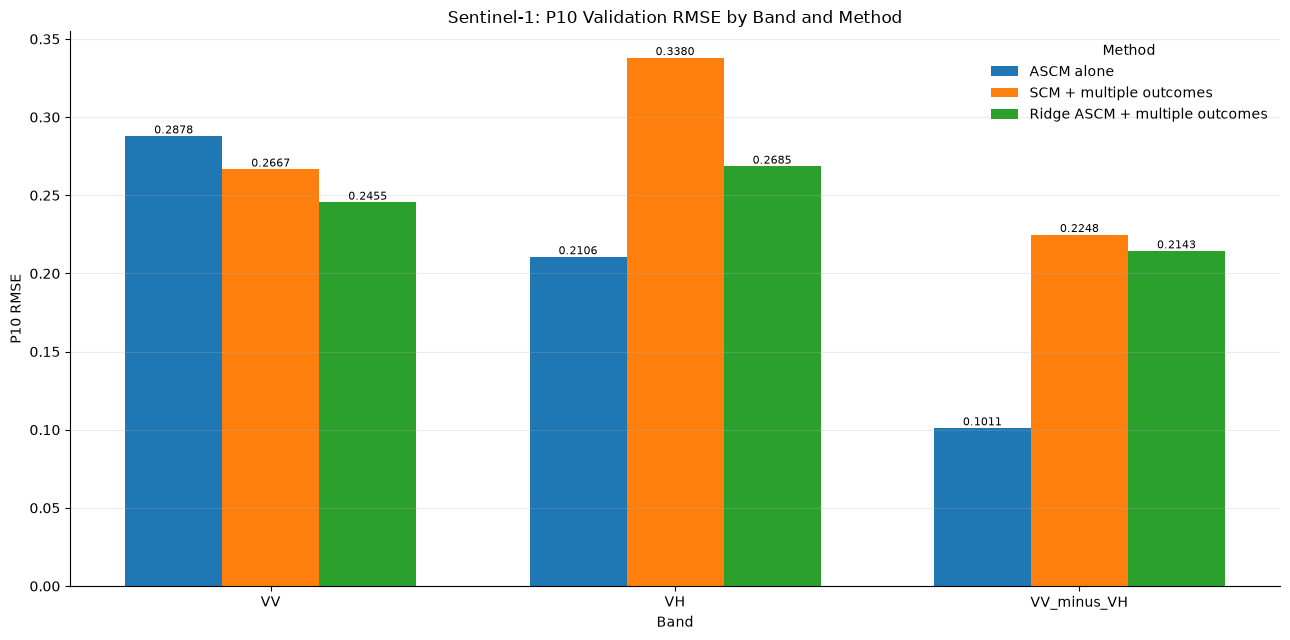

Saved: /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/figures/p10_rmse_by_band_three_methods_sentinel1.png


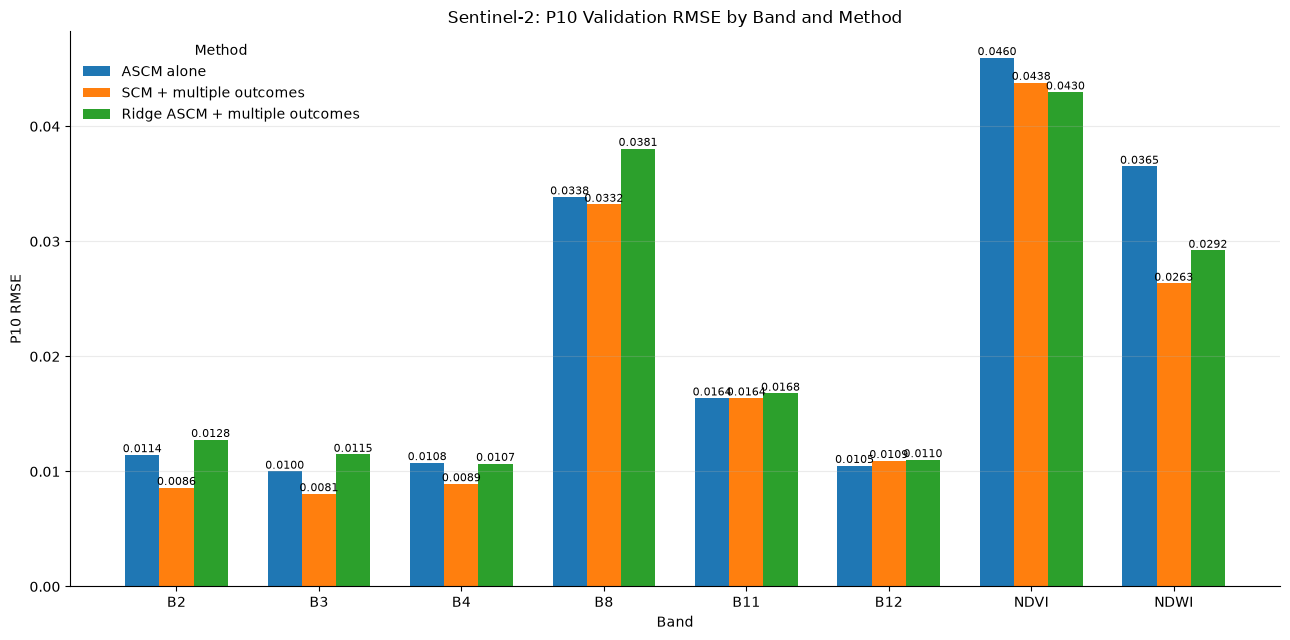

Saved: /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/figures/p10_rmse_by_band_three_methods_sentinel2.png

RMSE table:


,sensor,band,method,n_treatment_sites,mse,rmse,method_label
0,sentinel1,VH,ASCM_alone,12,0.044338,0.210567,ASCM alone
1,sentinel1,VH,Ridge_ASCM_multiple_outcomes,12,0.072102,0.268517,Ridge ASCM + multiple outcomes
2,sentinel1,VH,SCM_multiple_outcomes,12,0.114238,0.337991,SCM + multiple outcomes
3,sentinel1,VV,ASCM_alone,12,0.082856,0.287847,ASCM alone
4,sentinel1,VV,Ridge_ASCM_multiple_outcomes,12,0.060261,0.245480,Ridge ASCM + multiple outcomes
5,sentinel1,VV,SCM_multiple_outcomes,12,0.071104,0.266653,SCM + multiple outcomes
6,sentinel1,VV_minus_VH,ASCM_alone,12,0.010221,0.101097,ASCM alone
7,sentinel1,VV_minus_VH,Ridge_ASCM_multiple_outcomes,12,0.045944,0.214345,Ridge ASCM + multiple outcomes
8,sentinel1,VV_minus_VH,SCM_multiple_outcomes,12,0.050526,0.224780,SCM + multiple outcomes
9,sentinel2,B11,ASCM_alone,15,0.000268,0.016373,ASCM alone


In [16]:
# =============================================================================
# P10 RMSE FIGURES — THREE METHODS
# =============================================================================

FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METHOD_LABELS = {
    "ASCM_alone": "ASCM alone",
    "SCM_multiple_outcomes": "SCM + multiple outcomes",
    "Ridge_ASCM_multiple_outcomes": "Ridge ASCM + multiple outcomes",
}

METHOD_PLOT_ORDER = [
    "ASCM_alone",
    "SCM_multiple_outcomes",
    "Ridge_ASCM_multiple_outcomes",
]

BAND_ORDER = {
    "sentinel1": [
        "VV",
        "VH",
        "VV_minus_VH",
    ],
    "sentinel2": [
        "B2",
        "B3",
        "B4",
        "B8",
        "B11",
        "B12",
        "NDVI",
        "NDWI",
    ],
}

if validation.empty:
    rmse_by_band_method = pd.DataFrame()
    print("No P10 validation results available for RMSE figures.")
else:
    plot_data = validation.loc[
        validation["prediction_available"].eq(1)
        & validation["actual_P10"].notna()
        & validation["synthetic_P10"].notna()
    ].copy()

    rmse_by_band_method = (
        plot_data
        .groupby(
            ["sensor", "band", "method"],
            as_index=False,
        )
        .agg(
            n_treatment_sites=("treatment_site", "nunique"),
            mse=("squared_error_P10", "mean"),
        )
    )

    rmse_by_band_method["rmse"] = np.sqrt(
        rmse_by_band_method["mse"]
    )

    rmse_by_band_method["method_label"] = (
        rmse_by_band_method["method"]
        .map(METHOD_LABELS)
        .fillna(rmse_by_band_method["method"])
    )

    for sensor in ["sentinel1", "sentinel2"]:

        sensor_df = rmse_by_band_method.loc[
            rmse_by_band_method["sensor"].eq(sensor)
        ].copy()

        if sensor_df.empty:
            print(f"No RMSE results available for {sensor}.")
            continue

        available_bands = set(sensor_df["band"])

        bands = [
            band
            for band in BAND_ORDER[sensor]
            if band in available_bands
        ]

        pivot = (
            sensor_df
            .pivot(
                index="band",
                columns="method",
                values="rmse",
            )
            .reindex(bands)
        )

        x = np.arange(len(bands))
        width = 0.24

        fig, ax = plt.subplots(figsize=(13, 6.5))

        for method_index, method_name in enumerate(
            METHOD_PLOT_ORDER
        ):
            if method_name not in pivot.columns:
                continue

            offset = (
                method_index
                - (len(METHOD_PLOT_ORDER) - 1) / 2
            ) * width

            values = pivot[method_name].to_numpy(dtype=float)

            bars = ax.bar(
                x + offset,
                values,
                width,
                label=METHOD_LABELS[method_name],
            )

            for bar, value in zip(bars, values):
                if np.isfinite(value):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        value,
                        f"{value:.4f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                        rotation=0,
                    )

        sensor_title = (
            "Sentinel-1"
            if sensor == "sentinel1"
            else "Sentinel-2"
        )

        ax.set_title(
            f"{sensor_title}: P10 Validation RMSE by Band and Method"
        )
        ax.set_xlabel("Band")
        ax.set_ylabel("P10 RMSE")
        ax.set_xticks(x)
        ax.set_xticklabels(bands)
        ax.legend(title="Method", frameon=False)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.25)

        plt.tight_layout()

        figure_path = (
            FIGURE_DIR
            / f"p10_rmse_by_band_three_methods_{sensor}.png"
        )

        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        print("Saved:", figure_path)

print("\nRMSE table:")
display(rmse_by_band_method)


## Block 15 — Save all outputs

Main files to inspect first:

- `04_weight_changes_by_donor.csv` — donor-by-donor SCM vs ASCM weight changes.
- `05_weight_change_summary_by_site_sensor.csv` — how much the full weight vector moved and whether ASCM introduced negative weights.
- `10_scm_vs_ascm_validation_comparison.csv` — whether the ridge-adjusted weights improved held-out P10 fit.


In [17]:
# =============================================================================
# SAVE OUTPUTS
# =============================================================================

FEATURE_PANEL_FILE = OUTPUT_DIR / "01_monthly_feature_panel.csv"

ASCM_ALONE_WEIGHT_FILE = OUTPUT_DIR / "02_ascm_alone_weights.csv"
ASCM_ALONE_LAMBDA_FILE = OUTPUT_DIR / "03_ascm_alone_lambda_selection.csv"

SCM_MO_WEIGHT_FILE = OUTPUT_DIR / "04_scm_multiple_outcomes_weights.csv"
RIDGE_MO_WEIGHT_FILE = OUTPUT_DIR / "05_ridge_ascm_multiple_outcomes_weights.csv"
MO_WEIGHT_CHANGE_FILE = OUTPUT_DIR / "06_multioutcome_weight_changes_by_donor.csv"
MO_WEIGHT_CHANGE_SUMMARY_FILE = OUTPUT_DIR / "07_multioutcome_weight_change_summary.csv"
MO_LAMBDA_FILE = OUTPUT_DIR / "08_multioutcome_ridge_lambda_selection.csv"

VALIDATION_FILE = OUTPUT_DIR / "09_p10_validation_predictions_three_methods.csv"
VALIDATION_SITE_FILE = OUTPUT_DIR / "10_p10_validation_summary_by_site_sensor.csv"
VALIDATION_BAND_FILE = OUTPUT_DIR / "11_p10_validation_summary_by_band_method.csv"
COMPARISON_FILE = OUTPUT_DIR / "12_three_method_validation_comparison.csv"
RMSE_FILE = OUTPUT_DIR / "13_p10_rmse_by_band_method.csv"
DIAGNOSTICS_FILE = OUTPUT_DIR / "14_diagnostics.csv"

EXCEL_FILE = OUTPUT_DIR / "monthly_three_method_validation_results.xlsx"


features.to_csv(
    FEATURE_PANEL_FILE,
    index=False,
)

ascm_alone_weights_df.to_csv(
    ASCM_ALONE_WEIGHT_FILE,
    index=False,
)

ascm_alone_lambda_selection.to_csv(
    ASCM_ALONE_LAMBDA_FILE,
    index=False,
)

scm_multioutcome_weights_df.to_csv(
    SCM_MO_WEIGHT_FILE,
    index=False,
)

ridge_multioutcome_weights_df.to_csv(
    RIDGE_MO_WEIGHT_FILE,
    index=False,
)

weight_changes.to_csv(
    MO_WEIGHT_CHANGE_FILE,
    index=False,
)

weight_change_summary.to_csv(
    MO_WEIGHT_CHANGE_SUMMARY_FILE,
    index=False,
)

multioutcome_lambda_selection.to_csv(
    MO_LAMBDA_FILE,
    index=False,
)

validation.to_csv(
    VALIDATION_FILE,
    index=False,
)

validation_by_site_sensor.to_csv(
    VALIDATION_SITE_FILE,
    index=False,
)

validation_by_band.to_csv(
    VALIDATION_BAND_FILE,
    index=False,
)

validation_comparison.to_csv(
    COMPARISON_FILE,
    index=False,
)

rmse_by_band_method.to_csv(
    RMSE_FILE,
    index=False,
)

diagnostics.to_csv(
    DIAGNOSTICS_FILE,
    index=False,
)


# -----------------------------------------------------------------------------
# Excel workbook
# -----------------------------------------------------------------------------

try:
    with pd.ExcelWriter(
        EXCEL_FILE,
        engine="openpyxl",
    ) as writer:

        features.to_excel(
            writer,
            sheet_name="feature_panel",
            index=False,
        )

        ascm_alone_weights_df.to_excel(
            writer,
            sheet_name="ascm_alone_weights",
            index=False,
        )

        ascm_alone_lambda_selection.to_excel(
            writer,
            sheet_name="ascm_alone_lambda",
            index=False,
        )

        scm_multioutcome_weights_df.to_excel(
            writer,
            sheet_name="scm_multioutcome",
            index=False,
        )

        ridge_multioutcome_weights_df.to_excel(
            writer,
            sheet_name="ridge_mo_ascm",
            index=False,
        )

        weight_changes.to_excel(
            writer,
            sheet_name="mo_weight_changes",
            index=False,
        )

        weight_change_summary.to_excel(
            writer,
            sheet_name="mo_weight_change_summary",
            index=False,
        )

        multioutcome_lambda_selection.to_excel(
            writer,
            sheet_name="mo_ridge_lambda",
            index=False,
        )

        validation.to_excel(
            writer,
            sheet_name="p10_validation",
            index=False,
        )

        validation_by_site_sensor.to_excel(
            writer,
            sheet_name="validation_site_sensor",
            index=False,
        )

        validation_by_band.to_excel(
            writer,
            sheet_name="validation_band_method",
            index=False,
        )

        validation_comparison.to_excel(
            writer,
            sheet_name="three_method_comparison",
            index=False,
        )

        rmse_by_band_method.to_excel(
            writer,
            sheet_name="rmse_band_method",
            index=False,
        )

        diagnostics.to_excel(
            writer,
            sheet_name="diagnostics",
            index=False,
        )

    print("Excel workbook saved:", EXCEL_FILE)

except Exception as error:
    print("Excel export skipped/failed:", error)


print("\nSaved output files:")

for path in [
    FEATURE_PANEL_FILE,
    ASCM_ALONE_WEIGHT_FILE,
    ASCM_ALONE_LAMBDA_FILE,
    SCM_MO_WEIGHT_FILE,
    RIDGE_MO_WEIGHT_FILE,
    MO_WEIGHT_CHANGE_FILE,
    MO_WEIGHT_CHANGE_SUMMARY_FILE,
    MO_LAMBDA_FILE,
    VALIDATION_FILE,
    VALIDATION_SITE_FILE,
    VALIDATION_BAND_FILE,
    COMPARISON_FILE,
    RMSE_FILE,
    DIAGNOSTICS_FILE,
]:
    print(" -", path)


Excel workbook saved: /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/monthly_three_method_validation_results.xlsx

Saved output files:
 - /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/01_monthly_feature_panel.csv
 - /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/02_ascm_alone_weights.csv
 - /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/03_ascm_alone_lambda_selection.csv
 - /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/04_scm_multiple_outcomes_weights.csv
 - /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/05_ridge_ascm_multiple_outcomes_weights.csv
 - /Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly

## Block 16 — Final diagnostic summary


In [18]:
print("\n" + "=" * 100)
print("MONTHLY THREE-METHOD P10 VALIDATION COMPLETE")
print("=" * 100)

if not diagnostics.empty:
    success_counts = (
        diagnostics.loc[
            diagnostics["status"].eq("success")
        ]
        .groupby("method")
        .size()
    )

    print("\nSuccessful treatment × sensor analyses by method:")
    print(success_counts)

if not validation_by_band.empty:
    print("\nMean raw P10 RMSE across bands, by method:")

    mean_rmse_by_method = (
        validation_by_band
        .groupby("method")["validation_rmse"]
        .mean()
        .sort_values()
    )

    print(mean_rmse_by_method)

if not validation_comparison.empty:
    common = validation_comparison.dropna(
        subset=[
            "ascm_alone_rmse_std",
            "scm_multioutcome_rmse_std",
            "ridge_multioutcome_ascm_rmse_std",
        ]
    )

    if not common.empty:
        print("\nCommon-sample mean standardized P10 RMSE:")

        print(
            "ASCM alone:",
            common["ascm_alone_rmse_std"].mean(),
        )

        print(
            "SCM multiple outcomes:",
            common["scm_multioutcome_rmse_std"].mean(),
        )

        print(
            "Ridge ASCM + multiple outcomes:",
            common["ridge_multioutcome_ascm_rmse_std"].mean(),
        )

print("\nPrimary three-method comparison file:")
print(COMPARISON_FILE)

print("\nRMSE-by-band file:")
print(RMSE_FILE)

print("\nFigures folder:")
print(FIGURE_DIR)



MONTHLY THREE-METHOD P10 VALIDATION COMPLETE

Successful treatment × sensor analyses by method:
method
ASCM_alone                      27
Ridge_ASCM_multiple_outcomes    27
SCM_multiple_outcomes           27
dtype: int64

Mean raw P10 RMSE across bands, by method:
method
ASCM_alone                      0.070446
Ridge_ASCM_multiple_outcomes    0.081936
SCM_multiple_outcomes           0.089605
Name: validation_rmse, dtype: float64

Common-sample mean standardized P10 RMSE:
ASCM alone: 0.7425384491517022
SCM multiple outcomes: 0.8220604908755668
Ridge ASCM + multiple outcomes: 0.8560855523767755

Primary three-method comparison file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/12_three_method_validation_comparison.csv

RMSE-by-band file:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/monthly_three_methods_validation/13_p10_rmse_by_band_method.csv

Figures folder:
/Users/gaoyujuan/REAP Dropbox/Gao yu